```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 萨缪尔森乘数-加速器模型

```{contents} 目录
:depth: 2
```

除了Anaconda中已有的库外，这节课程还需要以下库：

In [1]:
!pip install quantecon

## 概述

本讲将介绍保罗·萨缪尔森著名的乘数加速模型,包括其非随机和随机两个版本 {cite}`Samuelson1939`。

在此过程中，我们将扩展[面向对象编程第二讲](https://python-programming.quantecon.org/python_oop.html)中的索洛模型类示例。

本讲的主要目标包括：

* 通过萨缪尔森模型深入学习面向对象编程和类的使用
* 深入理解这个经典的经济学模型
* 复习线性差分方程的相关知识，包括非随机和随机两种情况

让我们从一些标准的导入开始：

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"
mpl.font_manager.fontManager.addfont(FONTPATH)
plt.rcParams['font.family'] = ['Source Han Serif SC']

plt.rcParams["figure.figsize"] = (11, 5)  #设置默认图形大小
import numpy as np

我们还将使用以下内容来完成下面描述的各种任务：

In [3]:
from quantecon import LinearStateSpace
import cmath
import math
import sympy
from sympy import Symbol, init_printing
from cmath import sqrt

### 萨缪尔森模型

萨缪尔森（Samuelson）使用*二阶线性差分方程*来表示一个基于三个组成部分的国民产出模型：

- *国民产出恒等式*，表明国民产出或国民收入是消费、投资和政府购买的总和。
- 凯恩斯式的*消费函数*，表明$t$时期的消费等于一个常数乘以$t-1$时期的国民产出。
- 投资*加速器*，表明$t$时期的投资等于一个称为*加速系数*的常数乘以$t-1$时期和$t-2$时期产出之差。

消费、投资和政府购买的总和构成了*总需求*，这自动引致相同数量的*总供给*。

（关于线性差分方程的内容请参见[这里](https://en.wikipedia.org/wiki/Linear_difference_equation)或{cite}`Sargent1987`的第九章。）

萨缪尔森使用该模型分析了边际消费倾向和加速系数的特定值如何在国民产出中引发暂时性的**商业周期**。

可能的动态特性包括以下几种：

* 平滑收敛到一个固定的产出水平
* 最终收敛到固定产出水平的阻尼商业周期
* 既不衰减也不发散的持续性商业周期

后面我们将介绍一个扩展模型，在国民收入恒等式右侧加入一个随机冲击项，代表总需求的随机波动。

这一修改使国民产出受到二阶*随机线性差分方程*的影响，在适当的参数值下，会产生反复出现的不规则商业周期。

(关于随机线性差分方程的内容，请参见{cite}`Sargent1987`的第XI章。)

## 详细内容

让我们假设：

* $\{G_t\}$是一系列的政府支出水平 --
  我们先将所有时期的 $G_t = G$ 设为常数。
* $\{C_t\}$ 是总消费支出水平的序列，是模型中的一个关键内生变量。
* $\{I_t\}$ 是投资率的序列，是另一个关键内生变量。
* $\{Y_t\}$ 是国民收入水平的序列，也是一个内生变量。

- $\alpha$ 是凯恩斯消费函数 $C_t = \alpha Y_{t-1} + \gamma$ 中的边际消费倾向。
- $\beta$ 是"投资加速器" $I_t = \beta (Y_{t-1} - Y_{t-2})$ 中的"加速系数"。
- $\{\epsilon_{t}\}$ 是一个独立同分布的标准正态随机变量序列。
- $\sigma \geq 0$ 是一个"波动性"参数 --- 当设定 $\sigma = 0$ 时，
  我们将得到最初要研究的非随机情况。

该模型结合了消费函数

```{math}
:label: consumption

C_t = \alpha Y_{t-1} + \gamma
```

和投资加速器

```{math}
:label: accelerator

I_t = \beta (Y_{t-1} - Y_{t-2})
```

以及国民收入恒等式

```{math}
:label: income_identity

Y_t = C_t + I_t + G_t
```

- 参数 $\alpha$ 是人们的收入*边际消费倾向*
  - 方程 {eq}`consumption` 表明人们会消费每增加一美元收入中的 $\alpha \in (0,1)$ 部分。
- 参数 $\beta > 0$ 是投资加速系数 - 方程
  {eq}`accelerator` 表明当收入增加时人们会投资实物资本，当收入减少时会减少投资。

方程 {eq}`consumption`、{eq}`accelerator` 和 {eq}`income_identity`
推导出以下关于国民收入的二阶线性差分方程：

$$
Y_t = (\alpha+\beta) Y_{t-1} - \beta Y_{t-2} + (\gamma + G_t)
$$

或

```{math}
:label: second_order

Y_t = \rho_1 Y_{t-1} + \rho_2 Y_{t-2} + (\gamma + G_t)
```

其中 $\rho_1 = (\alpha+\beta)$ 且 $\rho_2 = -\beta$。

为完成这个模型，我们需要两个**初始条件**。

如果模型要生成 $t=0, \ldots, T$ 的时间序列，我们
需要初始值

$$
Y_{-1} = \bar Y_{-1}, \quad  Y_{-2} = \bar Y_{-2}
$$

我们通常会设置参数$(\alpha,\beta)$，使得从任意一对初始条件$(\bar Y_{-1}, \bar Y_{-2})$开始，国民收入$Y_t$在$t$变大时会收敛到一个常数值。

我们感兴趣的是研究

- $Y_t$在收敛到其**稳态**水平过程中的暂时波动
- 它收敛到稳态水平的**速率**

到目前为止我们讨论的是模型的确定性版本，即没有随机冲击影响总需求的情况，这种情况下模型只会产生暂时的波动。

我们可以通过在总需求中添加随机冲击，将模型转变为具有持续性、不规则波动的模型。

### 模型的随机版本

我们通过在方程{eq}`second_order`的右侧加入一个**冲击**或**扰动**的随机过程$\{\sigma \epsilon_t \}$，创建模型的**随机**版本，
由此得出**二阶标量线性随机差分方程**：

```{math}
:label: second_stochastic

Y_t = (\alpha+\beta) Y_{t-1} - \beta Y_{t-2} + (\gamma + G_t) + \sigma \epsilon_t
```

### 模型的数学分析

首先，让我们设定 $G_t \equiv 0$，$\sigma = 0$，以及
$\gamma = 0$。

然后我们可以将方程 {eq}`second_stochastic` 写作

$$
Y_t = \rho_1 Y_{t-1} + \rho_2 Y_{t-2}
$$

或

```{math}
:label: second_stochastic2

Y_{t+2} - \rho_1 Y_{t+1} - \rho_2 Y_t  = 0
```

为了发现 {eq}`second_stochastic2` 解的性质，
首先形成 {eq}`second_stochastic2` 的**特征多项式**是很有用的：

```{math}
:label: polynomial

z^2 - \rho_1 z  - \rho_2
```

其中 $z$ 可能是一个复数。

我们想要找到特征多项式的两个**零点**（又称**根**）-- 即
$\lambda_1, \lambda_2$。

这是两个特殊的 $z$ 值，即 $z= \lambda_1$ 和
$z= \lambda_2$，如果我们将 $z$ 设为
其中之一代入表达式 {eq}`polynomial`，
特征多项式 {eq}`polynomial` 等于零：

```{math}
:label: polynomial_sol

z^2 - \rho_1 z  - \rho_2  = (z- \lambda_1 ) (z -\lambda_2) = 0
```

方程 {eq}`polynomial_sol` 被称为特征多项式的**因式分解**。

当根为复数时，它们将以共轭复数对的形式出现。

当根为复数时，用极坐标形式表示它们会比较方便

$$
\lambda_1 =  r e^{i \omega}, \  \lambda_2 = r e^{-i \omega}
$$

其中 $r$ 是复数的*幅值*，而 $\omega$ 是其*角度*或*相位*。

这些也可以表示为

$$
\lambda_1 = r (cos (\omega) + i \sin (\omega))
$$

$$
\lambda_2 = r (cos (\omega) - i \sin(\omega))
$$

（要了解极坐标形式，请参见[这里](https://www.khanacademy.org/math/precalculus/x9e81a4f98389efdf:complex/x9e81a4f98389efdf:complex-mul-div-polar/a/complex-number-polar-form-review)）

给定**初始条件** $Y_{-1}, Y_{-2}$，我们想要生成差分方程 {eq}`second_stochastic2` 的**解**。

它可以表示为

$$
Y_t = \lambda_1^t c_1 + \lambda_2^t c_2
$$

其中 $c_1$ 和 $c_2$ 是取决于两个初始条件和 $\rho_1, \rho_2$ 的常数。

当根为复数时，以下的计算将非常有用。

注意

$$
\begin{aligned}
  Y_t & =   c_1 (r e^{i \omega})^t + c_2 (r e^{-i \omega})^t  \\
   & = c_1 r^t e^{i\omega t} + c_2 r^t e^{-i \omega t} \\
   & =  c_1 r^t [\cos(\omega t) + i \sin(\omega t) ] + c_2 r^t [\cos(\omega t) - i \sin(\omega t) ] \\
   & = (c_1 + c_2) r^t \cos(\omega t) + i (c_1 - c_2) r^t \sin(\omega t)
 \end{aligned}
$$

要使 $Y_t$ 对每个 $t$ 都是实数，唯一的方式是 $c_1 + c_2$ 为实数，而 $c_1 - c_2$ 为虚数。

这种情况只有当$c_1$和$c_2$是复共轭时才会发生，此时它们可以用极坐标形式表示为

$$
c_1 = v e^{i \theta},  \  \ c_2 = v e^{- i \theta}
$$

因此我们可以写成

$$
\begin{aligned}
  Y_t & = & v e^{i \theta} r^t e^{i \omega t} + v e ^{- i \theta} r^t e^{-i \omega t} \\
      & = & v r^t [ e^{i(\omega t + \theta)} + e^{-i (\omega t +\theta)}]  \\
      & = & 2 v r^t  \cos (\omega t + \theta)
 \end{aligned}
$$

其中$v$和$\theta$是确定的常数，可以通过$Y_{-1}, Y_{-2}$的初始条件得到。

这个公式表明，当根为复数时，$Y_t$表现出具有**周期**$\check p = \frac{2 \pi}{\omega}$和**衰减因子**$r$的振荡。

我们称$\check p$为**周期**，是因为在这段时间内，余弦波$\cos(\omega t + \theta)$恰好完成一个完整的周期。

（请画一个余弦函数来辅助自己理解）

**注释：** 遵循{cite}`Samuelson1939`，我们要选择模型的参数$\alpha, \beta$，使得特征多项式的（可能是复数的）根$\lambda_1, \lambda_2$的绝对值都严格小于1：

$$
| \lambda_j | < 1 \quad \quad \text{对于 } j = 1, 2
$$

**注释：** 当特征多项式的两个根$\lambda_1, \lambda_2$的绝对值都严格小于1时，较大根的绝对值决定了模型非随机版本向稳态收敛的速率。

### 本讲内容

我们编写一个函数来生成$\{Y_t\}$序列的模拟，将其作为时间的函数。

该函数需要我们输入$Y_{-1}, Y_{-2}$的初始条件。

该函数会检查$\alpha, \beta$的设置是否使得$\lambda_1, \lambda_2$的绝对值（也称为"模"）小于1。

该函数还会告诉我们根是否为复数，如果是复数，则会返回它们的实部和虚部。

如果两个根都是实数，函数会返回它们的值。

我们使用编写的函数来模拟随机路径（当$\sigma >0$时）。

我们编写函数的方式允许我们输入几种简单形式的$\{G_t\}$路径，例如：

* 在某个时间点$G$的一次性跳跃
* 在某个时间点发生的$G$的永久性跳跃

我们继续将萨缪尔森的乘数-加速器模型作为实验工具，用来构建一个简单的面向对象编程示例。

决定下一期$Y_{t+1}$的"状态"现在不仅仅是当前值$Y_t$，还包括滞后一期的值$Y_{t-1}$。

因此这比在 Solow 模型的类定义中所需的记录工作要稍微多一些。

我们以萨缪尔森的乘数-加速器模型为例，说明如何逐步为类添加功能。

我们希望在类中有一个方法可以自动生成模拟，既可以是非随机的（$\sigma=0$）也可以是随机的（$\sigma > 0$）。

我们还将展示如何将 Samuelson 模型映射到[这里](https://python.quantecon.org/linear_models.html)描述的`LinearStateSpace`类的一个简单实例中。

我们可以使用`LinearStateSpace`实例来完成上面用我们自制函数和类所做的各种事情。

除此之外，我们通过示例说明，我们用来形成 Samuelson 模型的`LinearStateSpace`类实例的矩阵 $A$ 的特征值，等于 Samuelson 乘数加速器模型的特征多项式{eq}`polynomial`的根。

以下是当政府支出为常数 $G$ 时，线性状态空间系统中矩阵 $A$ 的公式：

$$
A = \begin{bmatrix} 1 & 0 & 0 \cr
                      \gamma + G & \rho_1 & \rho_2 \cr
                      0 & 1 & 0 \end{bmatrix}
$$

## 实现

我们从 {cite}`Sargent1987` 第189页开始绘制一个信息丰富的图表

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


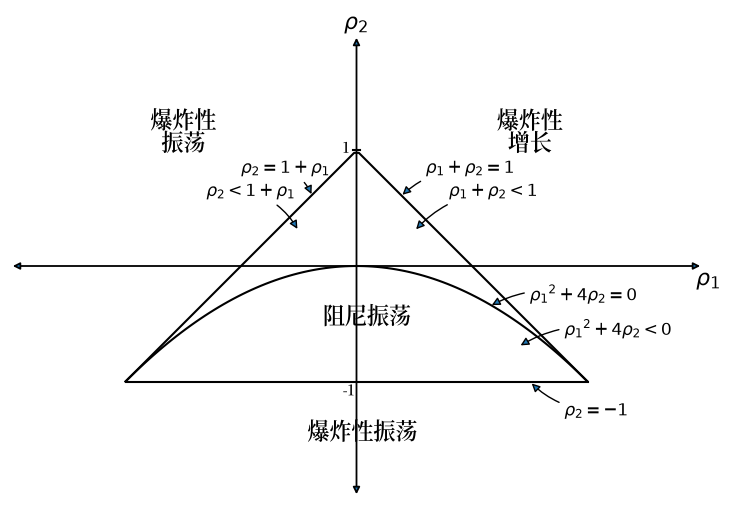

In [4]:
def param_plot():
    """该函数创建了Sargent宏观经济理论第二版(1987年)第189页的图表。
    """

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_aspect("equal")

    # 设置坐标轴
    xmin, ymin = -3, -2
    xmax, ymax = -xmin, -ymin
    plt.axis([xmin, xmax, ymin, ymax])

    # 设置坐标轴标签
    ax.set(xticks=[], yticks=[])
    ax.set_xlabel(r"$\rho_2$", fontsize=16)
    ax.xaxis.set_label_position("top")
    ax.set_ylabel(r"$\rho_1$", rotation=0, fontsize=16)
    ax.yaxis.set_label_position("right")

    # 绘制(t1, t2)点
    ρ1 = np.linspace(-2, 2, 100)
    ax.plot(ρ1, -abs(ρ1) + 1, c="black")
    ax.plot(ρ1, np.full_like(ρ1, -1), c="black")
    ax.plot(ρ1, -(ρ1**2 / 4), c="black")

    # 关闭普通坐标轴
    for spine in ["left", "bottom", "top", "right"]:
        ax.spines[spine].set_visible(False)

    # 添加表示坐标轴的箭头
    axes_arrows = {"arrowstyle": "<|-|>", "lw": 1.3}
    ax.annotate("", xy=(xmin, 0), xytext=(xmax, 0), arrowprops=axes_arrows)
    ax.annotate("", xy=(0, ymin), xytext=(0, ymax), arrowprops=axes_arrows)

    # 在图上标注方程
    plot_arrowsl = {"arrowstyle": "-|>", "connectionstyle": "arc3, rad=-0.2"}
    plot_arrowsr = {"arrowstyle": "-|>", "connectionstyle": "arc3, rad=0.2"}
    ax.annotate(
        r"$\rho_1 + \rho_2 < 1$",
        xy=(0.5, 0.3),
        xytext=(0.8, 0.6),
        arrowprops=plot_arrowsr,
        fontsize="12",
    )
    ax.annotate(
        r"$\rho_1 + \rho_2 = 1$",
        xy=(0.38, 0.6),
        xytext=(0.6, 0.8),
        arrowprops=plot_arrowsr,
        fontsize="12",
    )
    ax.annotate(
        r"$\rho_2 < 1 + \rho_1$",
        xy=(-0.5, 0.3),
        xytext=(-1.3, 0.6),
        arrowprops=plot_arrowsl,
        fontsize="12",
    )
    ax.annotate(
        r"$\rho_2 = 1 + \rho_1$",
        xy=(-0.38, 0.6),
        xytext=(-1, 0.8),
        arrowprops=plot_arrowsl,
        fontsize="12",
    )
    ax.annotate(
        r"$\rho_2 = -1$",
        xy=(1.5, -1),
        xytext=(1.8, -1.3),
        arrowprops=plot_arrowsl,
        fontsize="12",
    )
    ax.annotate(
        r"${\rho_1}^2 + 4\rho_2 = 0$",
        xy=(1.15, -0.35),
        xytext=(1.5, -0.3),
        arrowprops=plot_arrowsr,
        fontsize="12",
    )
    ax.annotate(
        r"${\rho_1}^2 + 4\rho_2 < 0$",
        xy=(1.4, -0.7),
        xytext=(1.8, -0.6),
        arrowprops=plot_arrowsr,
        fontsize="12",
    )

    # 标注解的类别
    ax.text(1.5, 1, "爆炸性\n增长", ha="center", fontsize=16)
    ax.text(-1.5, 1, "爆炸性\n振荡", ha="center", fontsize=16)
    ax.text(0.05, -1.5, "爆炸性振荡", ha="center", fontsize=16)
    ax.text(0.09, -0.5, "阻尼振荡", ha="center", fontsize=16)

    # 在y轴上添加小标记
    ax.axhline(y=1.005, xmin=0.495, xmax=0.505, c="black")
    ax.text(-0.12, -1.12, "-1", fontsize=10)
    ax.text(-0.12, 0.98, "1", fontsize=10)

    return fig


param_plot()
plt.show()

该图显示了在萨缪尔森模型中由差分方程参数对$(\rho_1 = (\alpha + \beta), \rho_2 = - \beta)$所隐含的$(\lambda_1, \lambda_2)$根对所在的区域，这些区域表示：

- $(\lambda_1, \lambda_2)$是复数且模小于$1$ - 在这种情况下，$\{Y_t\}$序列呈现衰减振荡。
- $(\lambda_1, \lambda_2)$都是实数，但其中一个严格大于$1$ - 这导致爆炸性增长。
- $(\lambda_1, \lambda_2)$都是实数，但其中一个严格小于$-1$ - 这导致爆炸性振荡。
- $(\lambda_1, \lambda_2)$都是实数且绝对值都小于$1$ - 在这种情况下，会平滑地收敛到稳态，没有衰减循环。

稍后我们将在图上用红色标记显示由$(\alpha, \beta)$设置所隐含的特定点。

### 描述特征多项式含义的函数

In [5]:
def categorize_solution(ρ1, ρ2):
    """
    该函数接收ρ1和ρ2的值，并用它们
    来分类解的类型。
    """
    discriminant = ρ1**2 + 4 * ρ2
    if ρ2 > 1 + ρ1 or ρ2 < -1:
        return "爆炸性振荡"
    elif ρ1 + ρ2 > 1:
        return "爆炸性增长"
    elif discriminant < 0:
        return "阻尼振荡"
    else:
        return "稳态收敛"

def analyze_roots(α, β, verbose=True):
    """
    统一的函数，用于计算根并分析其性质。
    """
    ρ1 = α + β
    ρ2 = -β
    
    # 计算特征多项式的根
    roots = np.roots([1, -ρ1, -ρ2])
    
    # 对解的类型进行分类
    solution_type = categorize_solution(ρ1, ρ2)
    
    # 确定根的性质
    is_complex = all(isinstance(root, complex) for root in roots)
    is_stable = all(abs(root) < 1 for root in roots)
    
    if verbose:
        print(f"ρ1 = {ρ1:.2f}, ρ2 = {ρ2:.2f}")
        print(f"根为: {[f'{root:.2f}' for root in roots]}")
        print(f"根的类型: {'复数' if is_complex else '实数'}")
        print(f"稳定性: {'稳定' if is_stable else '不稳定'}")
        print(f"解的类型: {solution_type}")
    
    return {
        'roots': roots,
        'rho1': ρ1,
        'rho2': ρ2,
        'is_complex': is_complex,
        'is_stable': is_stable,
        'solution_type': solution_type
    }

我们还编写了一个统一的模拟函数，可以处理模型的
非随机和随机版本。

它允许几种简单形式的政府支出路径，我们通过字典`g_params`来指定

In [6]:
def simulate_samuelson(
    y_0, y_1, α, β, γ=10, n=100, σ=0, g_params=None, seed=0
):
    """
    萨缪尔森模型的统一模拟函数。
    
    参数:
    g_params: 包含 'g'、'g_t'、'duration' 键的字典，用于政府支出
    seed: 用于结果可重复的随机种子
    """
    analysis = analyze_roots(α, β, verbose=False)
    ρ1, ρ2 = analysis['rho1'], analysis['rho2']
    
    # 初始化时间序列
    y_t = [y_0, y_1]
    
    # 如果是随机情形，生成冲击
    if σ > 0:
        np.random.seed(seed)
        ϵ = np.random.normal(0, 1, n)
    
    # 向前模拟
    for t in range(2, n):

        # 确定政府支出
        g = 0
        if g_params:
            g_val, g_t_val = g_params.get('g', 0), g_params.get('g_t', 0)
            duration = g_params.get('duration', None)
            if duration == 'permanent' and t >= g_t_val:
                g = g_val
            elif duration == 'one-off' and t == g_t_val:
                g = g_val
            elif duration is None:
                g = g_val
        
        # 计算下一个值
        y_next = ρ1 * y_t[t-1] + ρ2 * y_t[t-2] + γ + g
        if σ > 0:
            y_next += σ * ϵ[t]
        
        y_t.append(y_next)
    
    return y_t, analysis

我们将使用这个函数来运行模型的模拟。

但在此之前，让我们先测试一下分析函数

In [7]:
analysis = analyze_roots(α=1.3, β=0.4)

ρ1 = 1.70, ρ2 = -0.40
根为: ['1.42', '0.28']
根的类型: 实数
稳定性: 不稳定
解的类型: 爆炸性增长


### 绘制路径的函数

我们再定义一个对接下来的工作很有用的函数

In [8]:
def plot_y(function=None):
    """该函数用于绘制 Y_t 的路径"""

    plt.subplots(figsize=(10, 6))
    plt.plot(function)
    plt.xlabel('时间 $t$')
    plt.ylabel("$Y_t$")
    plt.show()

### 手动或"人工"求根计算

以下函数使用高中代数方法计算特征多项式的根。

（我们稍后会用`analyze_roots`以其他方式计算根）

该函数还根据我们设置的初始条件绘制 $Y_t$ 的图像

findfont: Failed to find font weight normal, now using 600.


ρ_1 是 1.42
ρ_2 是 -0.50
两个实根：
-0.65 -0.77
根的绝对值都小于1


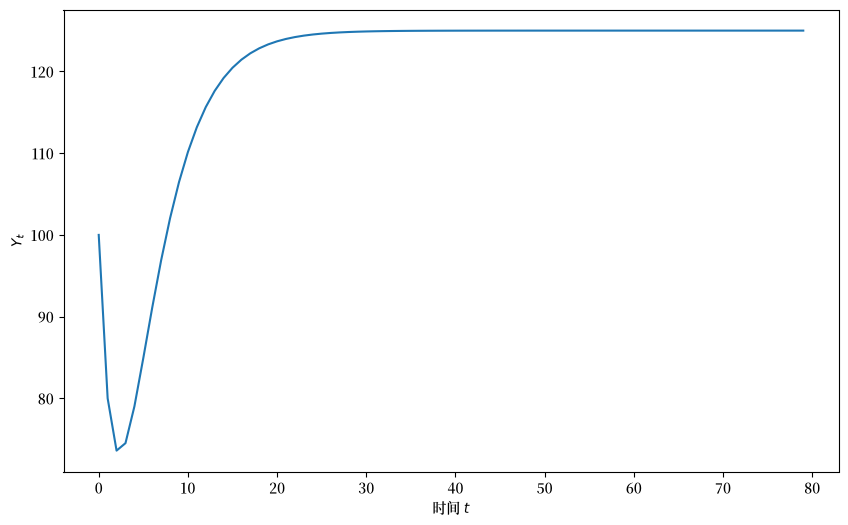

In [9]:
def y_nonstochastic(y_0=100, y_1=80, α=0.92, β=0.5, γ=10, n=80):
    """
    该函数手动计算特征多项式的根，
    并返回从初始条件开始的y_t路径
    """
    roots = []

    ρ1 = α + β
    ρ2 = -β

    print(f"ρ_1 是 {ρ1:.2f}")
    print(f"ρ_2 是 {ρ2:.2f}")

    discriminant = ρ1**2 + 4 * ρ2

    if discriminant == 0:
        roots.append(-ρ1 / 2)
        print("单个实根：")
        print("".join(f"{r:.2f}" for r in roots))
    elif discriminant > 0:
        roots.append((-ρ1 + sqrt(discriminant).real) / 2)
        roots.append((-ρ1 - sqrt(discriminant).real) / 2)
        print("两个实根：")
        print(" ".join(f"{r:.2f}" for r in roots))
    else:
        roots.append((-ρ1 + sqrt(discriminant)) / 2)
        roots.append((-ρ1 - sqrt(discriminant)) / 2)
        print("两个复根：")
        print(" ".join(f"{r.real:.2f}{r.imag:+.2f}j" for r in roots))

    if all(abs(root) < 1 for root in roots):
        print("根的绝对值都小于1")
    else:
        print("根的绝对值不都小于1")

    def transition(x, t):
        return ρ1 * x[t - 1] + ρ2 * x[t - 2] + γ

    y_t = [y_0, y_1]

    for t in range(2, n):
        y_t.append(transition(y_t, t))

    return y_t


plot_y(y_nonstochastic())

### 反向推导参数以生成阻尼周期

下一个单元格编写的代码以极坐标形式的一对共轭复数的模 $r$ 和相位 $\phi$ 作为输入

$$
\lambda_1 = r \exp(i \phi), \quad \lambda_2 = r \exp(- i \phi)
$$

- 代码假设这两个复数是特征多项式的根
- 然后反向推导出能生成这些根的 $(\alpha, \beta)$ 和 $(\rho_1, \rho_2)$ 对

In [10]:
def f(r, ϕ):
    """
    接收复数 r exp(j ϕ) 的模 r 和角度 ϕ，
    并创建特征多项式的 ρ1 和 ρ2，其中
    r exp(j ϕ) 和 r exp(- j ϕ) 是复根。

    返回验证这些根的乘数系数 $\alpha$
    和加速器系数 $\beta$。
    """
    # 从极坐标创建共轭复数对
    g1 = cmath.rect(r, ϕ)  # 生成两个复根
    g2 = cmath.rect(r, -ϕ)

    # 计算相应的 ρ1, ρ2 参数
    ρ1 = g1 + g2           # 隐含的 ρ1, ρ2
    ρ2 = -g1 * g2

    # 从 ρ 参数推导出 α 和 β 系数
    β = -ρ2                # 反向推导验证这些的 α 和 β
    α = ρ1 - β
    return ρ1, ρ2, α, β

现在让我们在示例中使用这个函数。

这里是示例参数

In [11]:
r = 0.95

# 时间单位中的周期长度
period = 10                # 时间单位中的周期长度
ϕ = 2 * math.pi / period

# 应用反向推导函数
ρ1, ρ2, α, β = f(r, ϕ)

print(f"α, β = {α:.2f}, {β:.2f}")
print(f"ρ1, ρ2 = {ρ1:.2f}, {ρ2:.2f}")

α, β = 0.63+0.00j, 0.90-0.00j
ρ1, ρ2 = 1.54+0.00j, -0.90+0.00j


根的实部为

In [12]:
print(f"ρ1 = {ρ1.real:.2f}, ρ2 = {ρ2.real:.2f}")

ρ1 = 1.54, ρ2 = -0.90


### 使用numpy求根

我们将使用numpy来计算特征多项式的根

In [13]:
r1, r2 = np.roots([1, -ρ1, -ρ2])

p1 = cmath.polar(r1)
p2 = cmath.polar(r2)

print(f"r, ϕ = {r:.2f}, {ϕ:.2f}")
print(f"p1, p2 = ({p1[0]:.2f}, {p1[1]:.2f}), ({p2[0]:.2f}, {p2[1]:.2f})")

print(f"α, β = {α:.2f}, {β:.2f}")
print(f"ρ1, ρ2 = {ρ1:.2f}, {ρ2:.2f}")

r, ϕ = 0.95, 0.63
p1, p2 = (0.95, 0.63), (0.95, -0.63)
α, β = 0.63+0.00j, 0.90-0.00j
ρ1, ρ2 = 1.54+0.00j, -0.90+0.00j


解的类型: 阻尼振荡
根为 [0.85+0.27838822j 0.85-0.27838822j]
根的类型: 复数
稳定性: 稳定


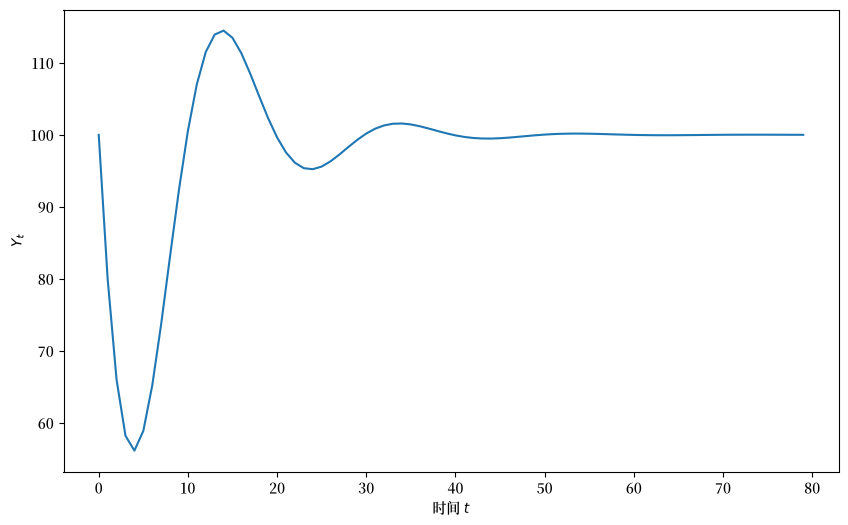

In [14]:
def y_nonstochastic(y_0=100, y_1=80, α=0.9, β=0.8, γ=10, n=80):
    """
    该函数使用numpy来计算特征多项式的根。
    """

    y_series, analysis = simulate_samuelson(y_0, y_1, α, β, γ, n, 0, None, 42)
    
    print(f"解的类型: {analysis['solution_type']}")
    print(f"根为 {analysis['roots']}")
    print(f"根的类型: {'复数' if analysis['is_complex'] else '实数'}")
    print(f"稳定性: {'稳定' if analysis['is_stable'] else '不稳定'}")
    
    return y_series


plot_y(y_nonstochastic())

### 反向推导复数根：示例

下一个单元研究反向推导复数根的含义。

我们将生成一个周期为10的**无阻尼**循环

α, β = 0.62, 1.00
解的类型: 阻尼振荡
根为 [0.80901699+0.58778525j 0.80901699-0.58778525j]
根的类型: 复数
稳定性: 稳定


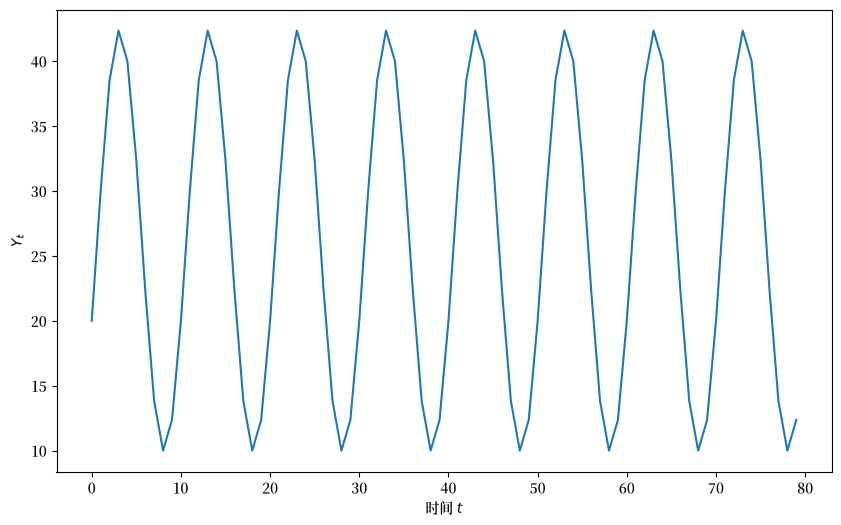

In [15]:
r = 1  # 生成无阻尼、非爆炸性循环

period = 10  # 时间单位中的循环长度
ϕ = 2 * math.pi / period

# 应用反向推导函数f
ρ1, ρ2, α, β = f(r, ϕ)

# 提取实部用于数值计算
α = α.real
β = β.real

print(f"α, β = {α:.2f}, {β:.2f}")

ytemp = y_nonstochastic(α=α, β=β, y_0=20, y_1=30)
plot_y(ytemp)

### 题外话：使用 Sympy 求根

我们也可以使用 sympy 来计算根的解析公式

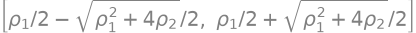

In [16]:
init_printing()

r1 = Symbol("ρ_1")
r2 = Symbol("ρ_2")
z = Symbol("z")

sympy.solve(z**2 - r1 * z - r2, z)

In [17]:
α = Symbol("α")
β = Symbol("β")
r1 = α + β
r2 = -β

sympy.solve(z**2 - r1 * z - r2, z)

## 随机冲击

现在我们将构建一些代码来模拟模型的随机版本，这个版本是通过在总需求中添加随机冲击过程而产生的

解的类型: 稳态收敛
根为 ['0.72', '0.28']
根的类型: 实数
稳定性: 稳定


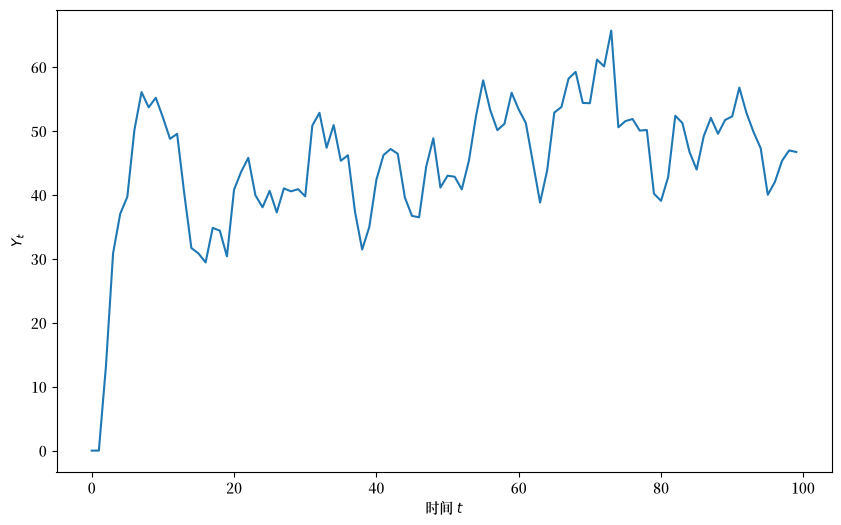

In [18]:
def y_stochastic(y_0=0, y_1=0, α=0.8, β=0.2, γ=10, n=100, σ=5):
    """
    该函数接收模型随机版本的参数，
    分析特征多项式的根，
    并生成一个模拟。
    """

    y_series, analysis = simulate_samuelson(y_0, y_1, α, β, γ, n, σ, None, 42)
    
    print(f"解的类型: {analysis['solution_type']}")
    print(f"根为 {[f'{root:.2f}' for root in analysis['roots']]}")
    print(f"根的类型: {'复数' if analysis['is_complex'] else '实数'}")
    print(f"稳定性: {'稳定' if analysis['is_stable'] else '不稳定'}")
    
    return y_series


plot_y(y_stochastic())

让我们进行一个模拟，其中存在冲击且特征多项式具有复根

α, β = 0.63, 0.94
解的类型: 阻尼振荡
根为 ['0.78+0.57j', '0.78-0.57j']
根的类型: 复数
稳定性: 稳定


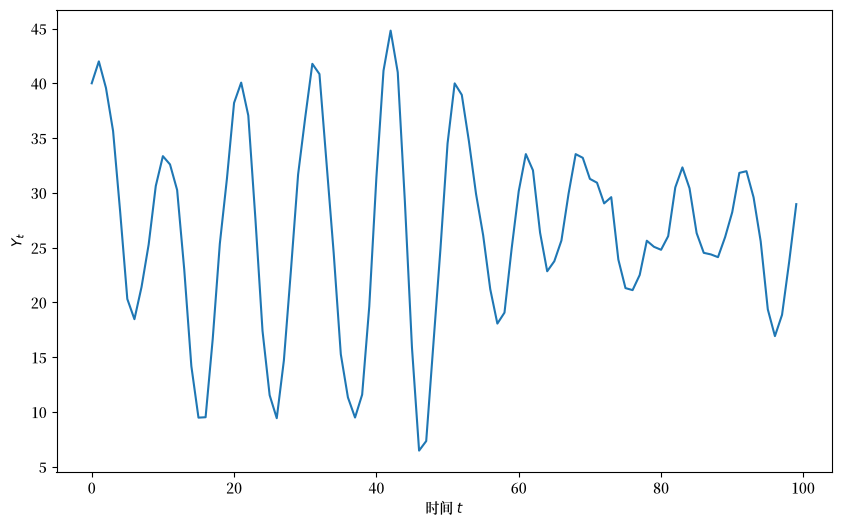

In [19]:
r = 0.97

period = 10  # 时间单位中的周期长度
ϕ = 2 * math.pi / period

# 应用反向推导函数f
ρ1, ρ2, α, β = f(r, ϕ)

# 提取实部用于数值计算
α = α.real
β = β.real

print(f"α, β = {α:.2f}, {β:.2f}")
plot_y(y_stochastic(y_0=40, y_1=42, α=α, β=β, σ=2, n=100))

## 政府支出

此函数计算对政府支出的永久性或一次性增加的响应

In [20]:
def y_stochastic_g(
    y_0=20, y_1=20, α=0.8, β=0.2, γ=10,
    n=100, σ=2, g=0, g_t=0, duration="permanent"
):
    """
    此程序计算在时间20发生的政府支出
    永久性增加的响应
    """

    g_params = (
        {'g': g, 'g_t': g_t, 'duration': duration} if g != 0 else None
    )
    y_series, analysis = simulate_samuelson(
        y_0, y_1, α, β, γ, n, σ, g_params, 42
    )
    
    print(f"解的类型: {analysis['solution_type']}")
    print(f"根: {analysis['roots']}")
    print(f"根的类型: {'复数' if analysis['is_complex'] else '实数'}")
    print(f"稳定性: {'稳定' if analysis['is_stable'] else '不稳定'}")
    
    return y_series

可以按以下方式模拟永久性政府支出冲击

解的类型: 稳态收敛
根: [0.7236068 0.2763932]
根的类型: 实数
稳定性: 稳定


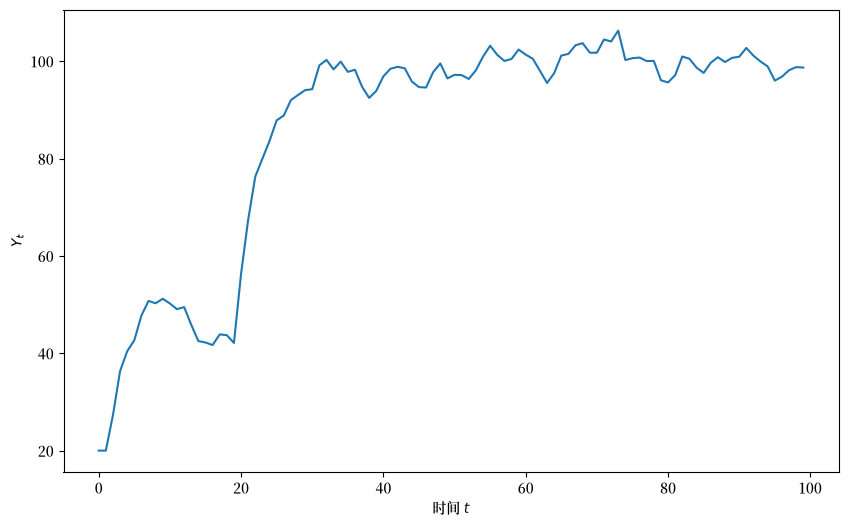

In [21]:
plot_y(y_stochastic_g(g=10, g_t=20, duration="permanent"))

我们还可以观察一次性政府支出增加所带来的响应

解的类型: 稳态收敛
根: [0.7236068 0.2763932]
根的类型: 实数
稳定性: 稳定


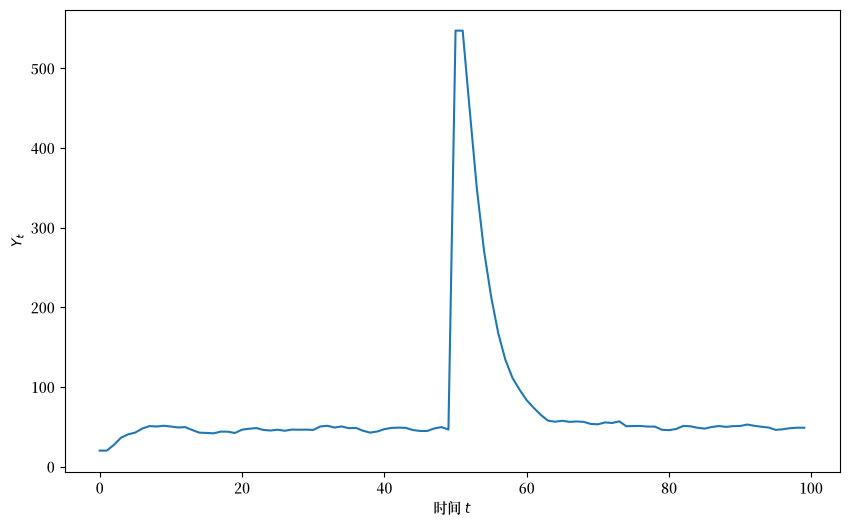

In [22]:
plot_y(y_stochastic_g(g=500, g_t=50, duration="one-off"))

## 将所有内容封装到类中

到目前为止，我们已经编写了函数来完成工作。

现在让我们撸起袖子，为萨缪尔森模型编写一个名为`Samuelson`的Python类

In [23]:
class Samuelson:
    """
    这个类代表萨缪尔森模型，也称为多重加速器模型。
    该模型将凯恩斯乘数与投资加速器理论相结合。

    产出路径由线性二阶差分方程控制

    .. math::

        Y_t = \alpha (1 + \beta) Y_{t-1} - \alpha \beta Y_{t-2}

    参数
    ----------
    y_0 : 标量
        Y_0的初始条件
    y_1 : 标量
        Y_1的初始条件
    α : 标量
        边际消费倾向
    β : 标量
        加速器系数
    n : 整数
        迭代次数
    σ : 标量
        波动性参数。必须大于或等于0。设为0表示非随机模型。
    g : 标量
        政府支出冲击
    g_t : 整数
        政府支出冲击发生的时间。当duration != None时必须指定。
    duration : {None, 'permanent', 'one-off'}
        指定政府支出冲击的类型。如果为none，则所有t的政府支出等于g。

    """

    def __init__(
        self, y_0=100, y_1=50,
        α=1.3, β=0.2, γ=10, n=100, σ=0, g=0, g_t=0, duration=None
    ):

        self.y_0, self.y_1, self.α, self.β = y_0, y_1, α, β
        self.n, self.g, self.g_t, self.duration = n, g, g_t, duration
        self.γ, self.σ = γ, σ
        
        # 使用统一的分析函数
        self.analysis = analyze_roots(α, β, verbose=False)
        self.ρ1, self.ρ2 = self.analysis['rho1'], self.analysis['rho2']
        self.roots = self.analysis['roots']

    def root_type(self):
        return "复共轭" if self.analysis['is_complex'] else "实数"

    def root_less_than_one(self):
        return self.analysis['is_stable']

    def solution_type(self):
        return self.analysis['solution_type']

    def generate_series(self, seed=0):
        g_params = (
            {'g': self.g, 'g_t': self.g_t, 'duration': self.duration} 
            if self.g != 0 else None
        )
        y_series, _ = simulate_samuelson(
            self.y_0, self.y_1, self.α, self.β, self.γ, 
            self.n, self.σ, g_params, seed
        )
        return y_series

    def summary(self):
        print("摘要\n" + "-" * 50)
        print(f"根的类型: {self.root_type()}")
        print(f"解的类型: {self.solution_type()}")
        print(f"根: {str(self.roots)}")

        if self.root_less_than_one() == True:
            print("根的绝对值小于1")
        else:
            print("根的绝对值不小于1")

        if self.σ > 0:
            print("随机序列，σ = " + str(self.σ))
        else:
            print("非随机序列")

        if self.g != 0:
            print("政府支出等于 " + str(self.g))

        if self.duration != None:
            print(
                self.duration.capitalize()
                + " 政府支出冲击发生在 t = "
                + str(self.g_t)
            )

    def plot(self, seed=0):
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(self.generate_series(seed))
        ax.set(xlabel="迭代次数", xlim=(0, self.n))
        ax.set_ylabel("$Y_t$", rotation=0)

        # 在图中添加参数值
        paramstr = (
            f"$α={self.α:.2f}$ \n $β={self.β:.2f}$ \n "
            f"$\\gamma={self.γ:.2f}$ \n $\\sigma={self.σ:.2f}$ \n "
            f"$\\rho_1={self.ρ1:.2f}$ \n $\\rho_2={self.ρ2:.2f}$"
        )
        props = dict(fc="white", pad=10, alpha=0.5)
        ax.text(
            0.87,
            0.05,
            paramstr,
            transform=ax.transAxes,
            fontsize=12,
            bbox=props,
            va="bottom",
        )

        return fig

    def param_plot(self):


        fig = param_plot()
        ax = fig.gca()

        # 在图例中显示特征值
        for i, root in enumerate(self.roots):
            if isinstance(root, complex):

                # 处理复数显示的符号格式
                operator = ["+", ""]
                root_real = self.roots[i].real
                root_imag = self.roots[i].imag
                label = (
                    rf"$\lambda_{i+1} = {root_real:.2f}"
                    rf"{operator[i]} {root_imag:.2f}i$"
                )
            else:
                label = rf"$\lambda_{i+1} = {self.roots[i].real:.2f}$"

            # 添加不可见的点以生成图例条目
            ax.scatter(
                0, 0, s=0, label=label
            )

        # 在稳定性图上标出当前参数值
        ax.scatter(
            self.ρ1,
            self.ρ2,
            s=100,
            c="red",
            marker="+",
            label=r"$(\rho_1, \rho_2)$",
            zorder=5,
        )

        plt.legend(fontsize=12, loc=3)

        return fig

### Samuelson类的说明

现在我们用一个例子来展示Samuelson类的应用

In [24]:
sam = Samuelson(α=0.8, β=0.5, σ=2, g=10, g_t=20, duration="permanent")
sam.summary()

摘要
--------------------------------------------------
根的类型: 复共轭
解的类型: 阻尼振荡
根: [0.65+0.27838822j 0.65-0.27838822j]
根的绝对值小于1
随机序列，σ = 2
政府支出等于 10
Permanent 政府支出冲击发生在 t = 20


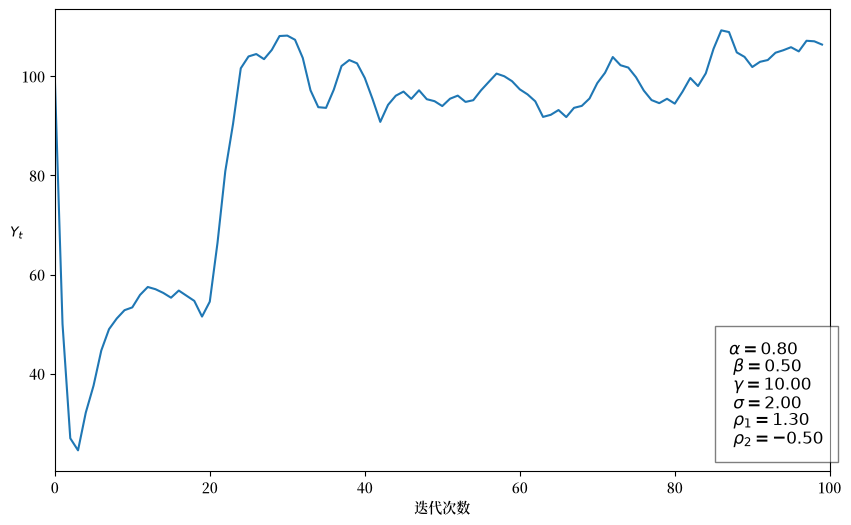

In [25]:
sam.plot()
plt.show()

### 使用图形

我们将使用我们的图形来显示根的位置，并说明它们的位置如何与刚才绘制的路径行为相一致。

红色的 $+$ 符号显示了根的位置

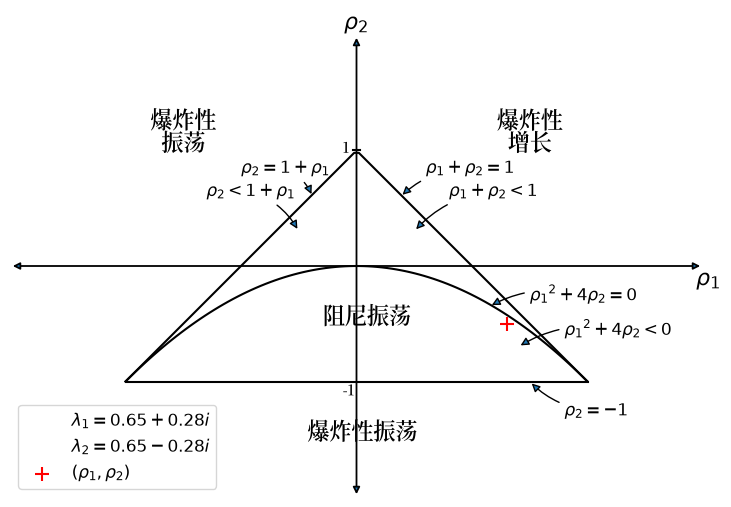

In [26]:
sam.param_plot()
plt.show()

## 使用LinearStateSpace类

我们可以使用[QuantEcon.py](https://quantecon.org/quantecon-py/)中的[LinearStateSpace](https://github.com/QuantEcon/QuantEcon.py/blob/master/quantecon/lss.py)类来完成我们之前从头开始做的大部分工作。

以下是我们如何将萨缪尔森模型映射到`LinearStateSpace`类的实例中

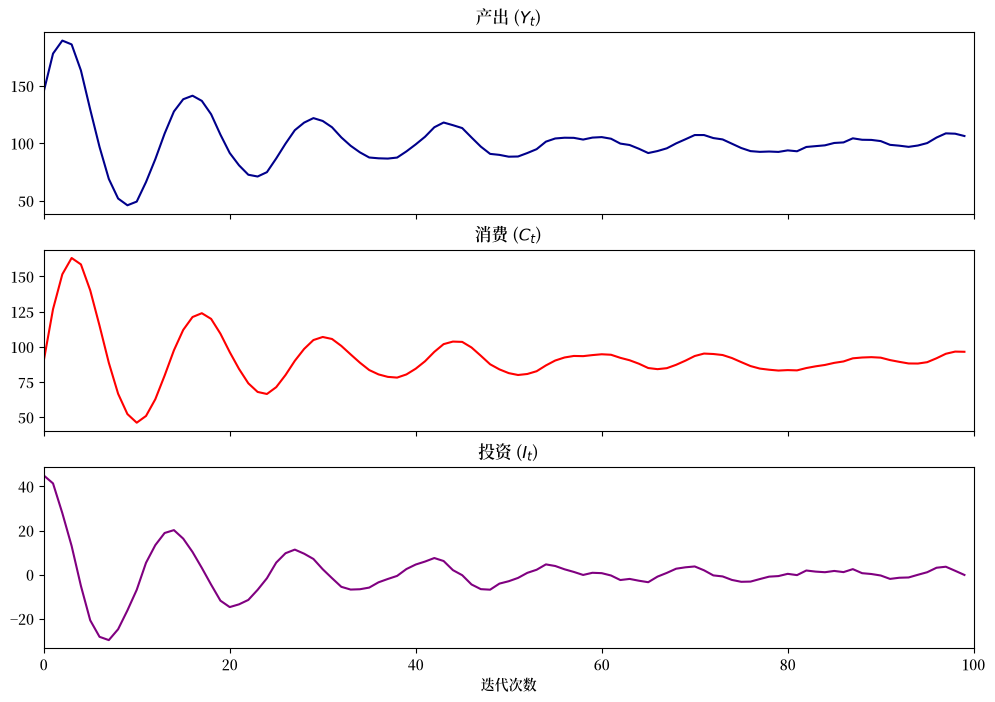

In [27]:
α = 0.8
β = 0.9
ρ1 = α + β
ρ2 = -β
γ = 10
σ = 1
g = 10
n = 100

A = [[1, 0, 0], [γ + g, ρ1, ρ2], [0, 1, 0]]

G = [
    [γ + g, ρ1, ρ2],  # Y_{t+1}
    [γ, α, 0],        # C_{t+1}
    [0, β, -β],       # I_{t+1}
]

μ_0 = [1, 100, 50]
C = np.zeros((3, 1))
C[1] = σ  # 随机项

sam_t = LinearStateSpace(A, C, G, mu_0=μ_0)

x, y = sam_t.simulate(ts_length=n)

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 8))
titles = ["产出 ($Y_t$)", "消费 ($C_t$)", "投资 ($I_t$)"]
colors = ["darkblue", "red", "purple"]
for ax, series, title, color in zip(axes, y, titles, colors):
    ax.plot(series, color=color)
    ax.set(title=title, xlim=(0, n))

axes[-1].set_xlabel("迭代次数")

plt.show()

### `LinearStateSpace` 类中的其他方法

让我们使用 `LinearStateSpace` 类中的方法为萨缪尔森模型的实例绘制**脉冲响应函数**

In [28]:
imres = sam_t.impulse_response()
imres = np.asarray(imres)
y1 = imres[:, :, 0]
y2 = imres[:, :, 1]
y1.shape

现在让我们通过计算矩阵$A$的特征值来求解特征多项式的零点

In [29]:
A = np.asarray(A)
w, v = np.linalg.eig(A)
print(np.round(w, 2))

[0.85+0.42j 0.85-0.42j 1.  +0.j  ]


### 从 `LinearStateSpace` 继承方法

我们也可以创建 `LinearStateSpace` 的子类（继承其所有方法和属性）来添加更多可用的函数

In [30]:
class SamuelsonLSS(LinearStateSpace):
    """
    这个子类将萨缪尔森乘数-加速器模型
    创建为线性状态空间系统。
    """

    def __init__(self, y_0=100, y_1=50, α=0.8, β=0.9, γ=10, σ=1, g=10):

        self.α, self.β = α, β
        self.y_0, self.y_1, self.g = y_0, y_1, g
        self.γ, self.σ = γ, σ

        # 设置初始状态向量
        self.initial_μ = [1, y_0, y_1]

        self.ρ1 = α + β
        self.ρ2 = -β

        # 构造状态转移矩阵
        self.A = [[1, 0, 0], [γ + g, self.ρ1, self.ρ2], [0, 1, 0]]

        # 构造观测矩阵
        self.G = [
            [γ + g, self.ρ1, self.ρ2],  # Y_{t+1}
            [γ, α, 0],                  # C_{t+1}
            [0, β, -β],                 # I_{t+1}
        ]  

        self.C = np.zeros((3, 1))
        self.C[1] = σ  # 随机项

        # 初始化 LinearStateSpace 实例
        LinearStateSpace.__init__(
            self, self.A, self.C, self.G, mu_0=self.initial_μ
        )

    # 为父类中的 mu_0 和 Sigma_0 创建 unicode 别名
    @property
    def μ_0(self):
        return self.mu_0
    
    @μ_0.setter
    def μ_0(self, value):
        self.mu_0 = value
    
    @property
    def Σ_0(self):
        return self.Sigma_0
    
    @Σ_0.setter
    def Σ_0(self, value):
        self.Sigma_0 = value

    def plot_simulation(self, ts_length=100, stationary=True, seed=0):

        # 存储原始分布参数
        temp_μ = self.μ_0
        temp_Σ = self.Σ_0

        # 使用平稳分布进行模拟
        if stationary == True:
            try:
                (self.μ_x, self.μ_y, self.Σ_x, self.Σ_y, self.Σ_yx
                ) = self.stationary_distributions()
                self.μ_0 = self.μ_x
                self.Σ_0 = self.Σ_x

            # 处理平稳分布不存在的情况
            except ValueError:
                print("平稳分布不存在")

        np.random.seed(seed)
        x, y = self.simulate(ts_length)

        fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 8))
        titles = ["产出 ($Y_t$)", 
                  "消费 ($C_t$)", 
                  "投资 ($I_t$)"]
        colors = ["darkblue", "red", "purple"]
        for ax, series, title, color in zip(axes, y, titles, colors):
            ax.plot(series, color=color)
            ax.set(title=title, xlim=(0, n))

        axes[-1].set_xlabel("迭代次数")
        plt.show()

        # 恢复原始分布参数
        self.μ_0 = temp_μ
        self.Σ_0 = temp_Σ

    def plot_irf(self, j=5):

        x, y = self.impulse_response(j)

        # 重塑脉冲响应以便绘图
        yimf = np.array(y).flatten().reshape(j + 1, 3).T

        fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 8))
        labels = ["$Y_t$", "$C_t$", "$I_t$"]
        colors = ["darkblue", "red", "purple"]
        for ax, series, label, color in zip(axes, yimf, labels, colors):
            ax.plot(series, color=color)
            ax.set(xlim=(0, j))
            ax.set_ylabel(label, rotation=0, fontsize=14, labelpad=10)

        axes[0].set_title("脉冲响应函数")
        axes[-1].set_xlabel("迭代次数")
        plt.show()

    def multipliers(self, j=5):
        x, y = self.impulse_response(j)
        return np.sum(np.array(y).flatten().reshape(j + 1, 3), axis=0)

### 图示

让我们展示如何使用`SamuelsonLSS`

In [31]:
samlss = SamuelsonLSS()

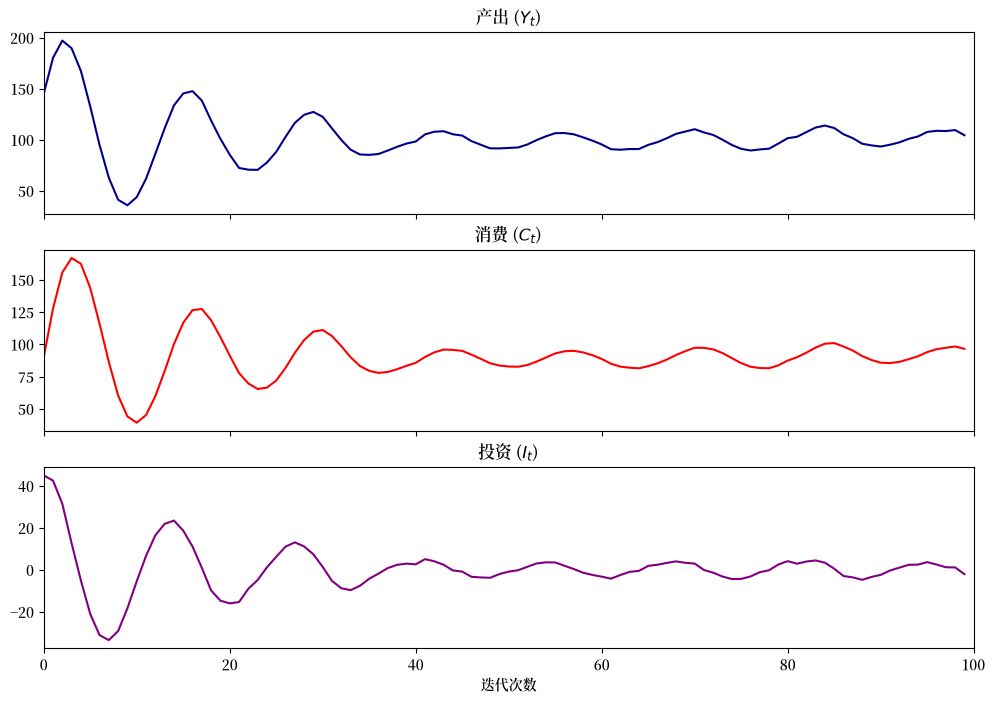

In [32]:
samlss.plot_simulation(100, stationary=False)
plt.show()

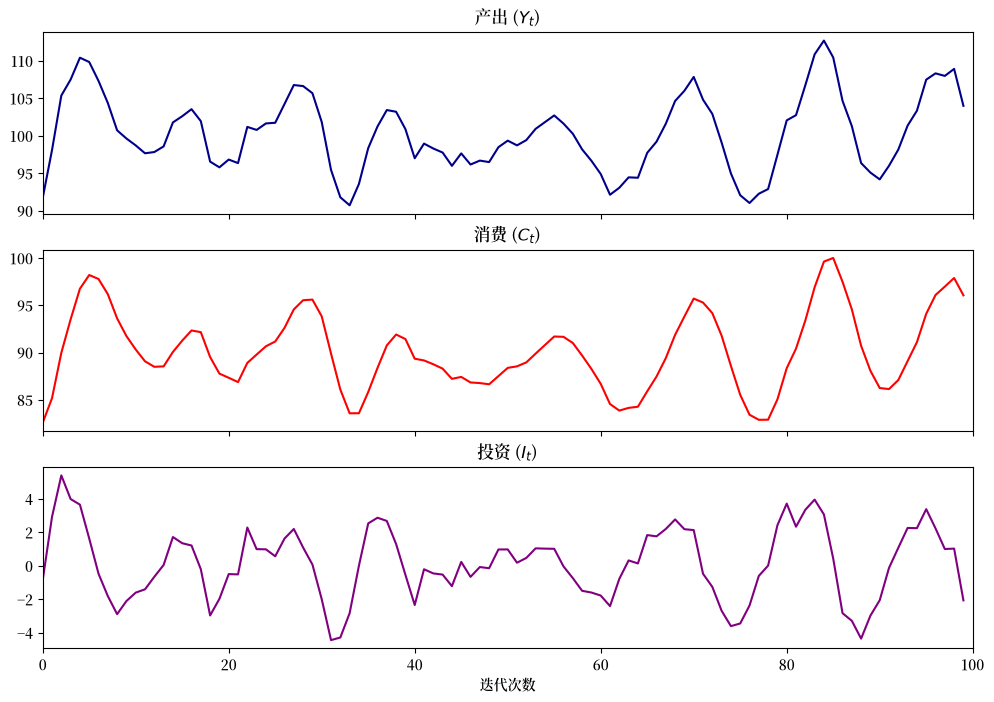

In [33]:
samlss.plot_simulation(100, stationary=True)
plt.show()

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


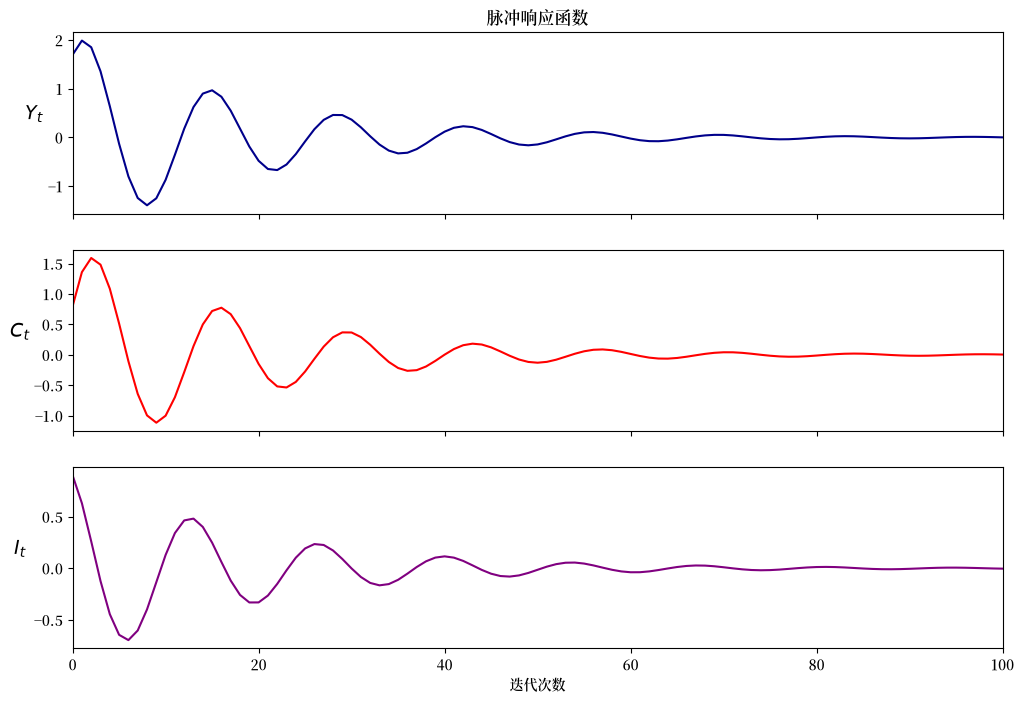

In [34]:
samlss.plot_irf(100)
plt.show()

In [35]:
samlss.multipliers()

array([7.414389, 6.835896, 0.578493])

## 纯乘数模型

让我们通过设置 $b=0$ 来关闭加速器，得到一个纯乘数模型

- 缺少周期性的现象说明了为什么萨缪尔森要引入加速器

In [36]:
pure_multiplier = SamuelsonLSS(α=0.95, β=0)

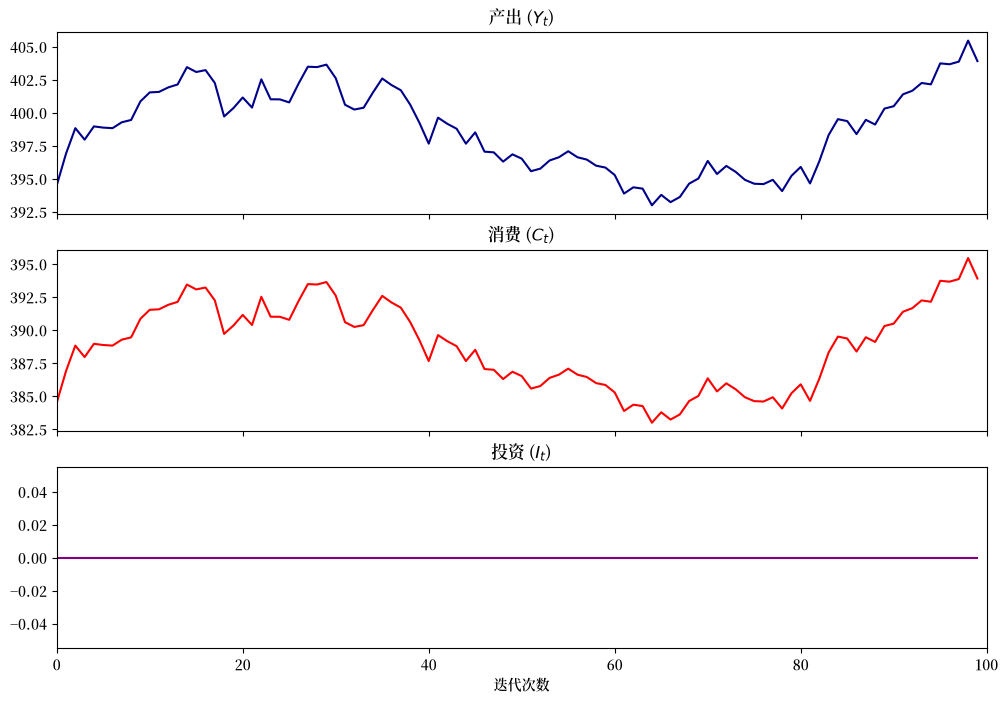

In [37]:
pure_multiplier.plot_simulation()

In [38]:
pure_multiplier = SamuelsonLSS(α=0.8, β=0)

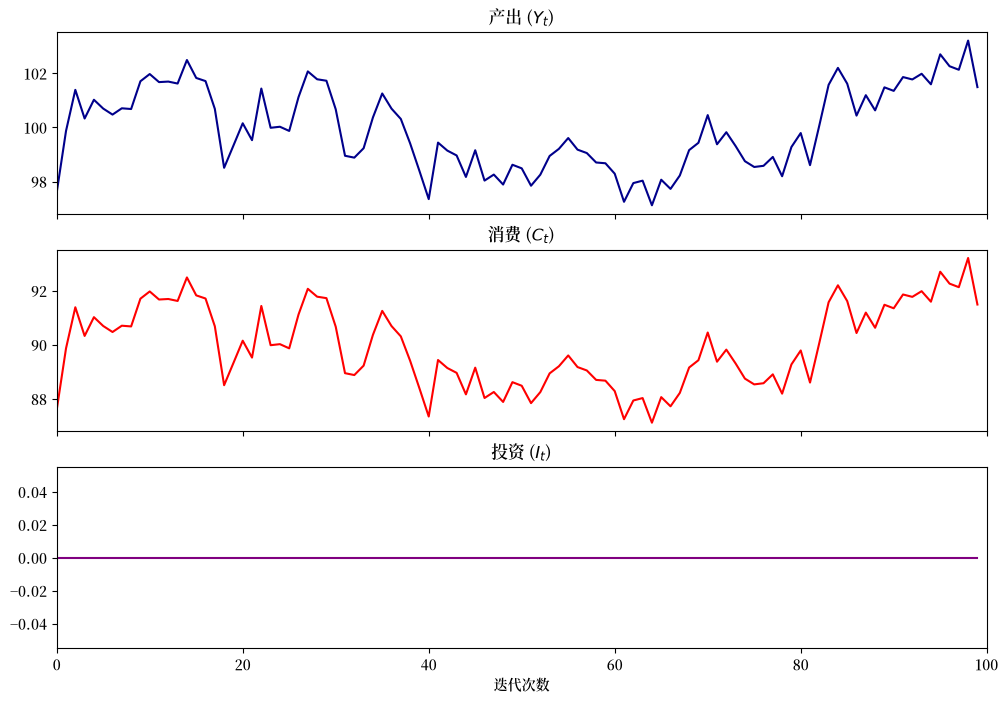

In [39]:
pure_multiplier.plot_simulation()

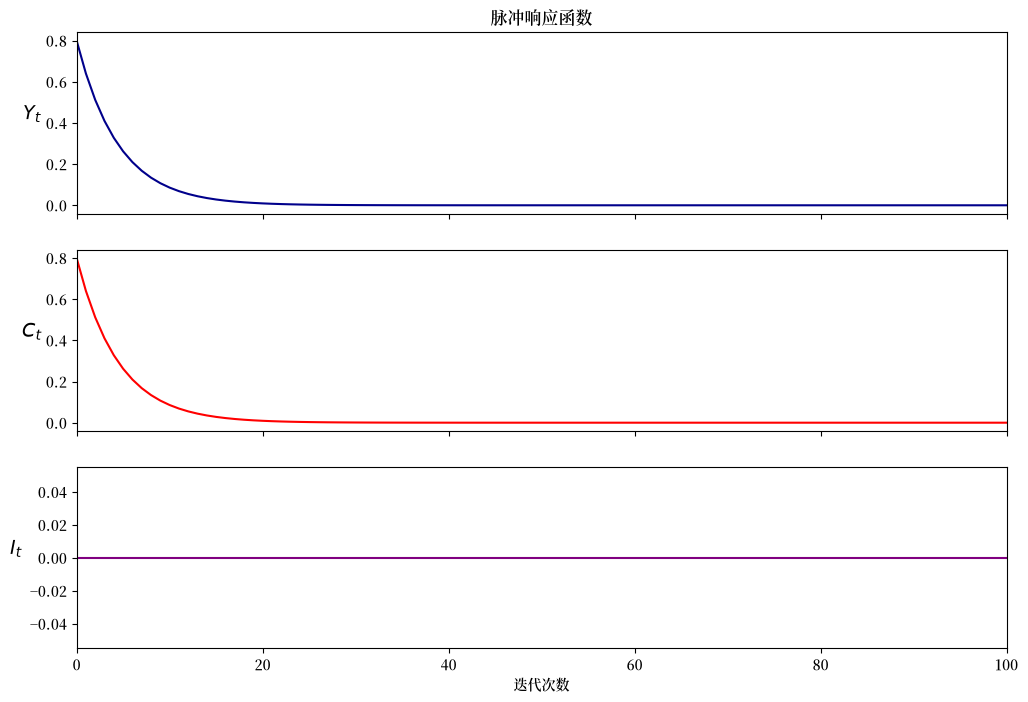

In [40]:
pure_multiplier.plot_irf(100)

## 总结

在本讲中，我们编写了函数和类来表示萨缪尔森(1939)乘数-加速器模型的非随机和随机版本，该模型在{cite}`Samuelson1939`中有所描述。

我们看到不同的参数值会导致不同的输出路径，这些路径可能是平稳的、发散的或振荡的。

我们还能够使用[QuantEcon.py](https://quantecon.org/quantecon-py/)的[LinearStateSpace](https://github.com/QuantEcon/QuantEcon.py/blob/master/quantecon/lss.py)类来表示该模型。